# Checking if Lasso Rolling window returns the correct parameters when the DGP is stable

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
from typing import Tuple, Optional, Dict, Any, List
from tqdm import tqdm
import matplotlib.pyplot as plt

## Case 1) contemporanteous X on y, we set n_lags = 0

In [12]:
def create_lagged_features(X: np.ndarray, n_lags: int = 3):
    if n_lags == 0:
        return X, [f'feature_{i}' for i in range(X.shape[1])]

    n_samples, n_features = X.shape

    # Create lagged blocks in the correct order: lag 1, lag 2, ...
    lagged_features = [
        X[n_lags - lag : n_samples - lag] 
        for lag in range(1, n_lags + 1)
    ]

    feature_names = [
        f'feature_{i}_lag_{lag}'
        for lag in range(1, n_lags + 1)
        for i in range(n_features)
    ]

    return np.hstack(lagged_features), feature_names

        

In [3]:
def lasso_rolling_window(X: np.ndarray,
                         y: np.ndarray,
                         window_size: int = 30,
                         n_lags: int = 3,
                         burn_in: Optional[int] = None,
                         standardize: bool = True,
                         cv_folds: int = 5,
                         alphas: Optional[np.ndarray] = None,
                         verbose: bool = True,
                         lambda_mode: str = "cv",
                         fixed_lambda: Optional[float] = None) -> Dict[str, Any]:
    
    

    # Extract date index if pandas object
    date_index = y.index if isinstance(y, (pd.Series, pd.DataFrame)) else None
    y = np.asarray(y).flatten()
    X = np.asarray(X)
    
    # Center returns
    mean_y = np.nanmean(y)
    y = y - mean_y
    

    # Create lagged features
    if verbose:
        print(f"Creating lagged features with {n_lags} lags...")
    
    X_lagged, feature_names = create_lagged_features(X, n_lags)
    y_aligned = y[n_lags:]


    
    if date_index is not None:
        date_index = date_index[n_lags:]
    

    # Safety Checks
    if X_lagged.shape[0] != y_aligned.shape[0]:
        raise ValueError("Mismatch between lagged X and aligned y observations.")
    
    burn_in = burn_in or window_size
    if len(y_aligned) < burn_in:
        raise ValueError("Insufficient data for window size and lags.")
    
    if lambda_mode not in {"cv", "fixed"}:
        raise ValueError("lambda_mode must be 'cv' or 'fixed'.")
    
    if lambda_mode == "fixed" and (fixed_lambda is None or fixed_lambda <= 0):
        raise ValueError("lambda_mode='fixed' requires positive fixed_lambda.")
    

    # Initialize storage for results
    results_data = {
        # LASSO Storage
        'lambdas': [], 'coefficients': [], 'intercepts': [], 'insample_r_squareds': [], 'num_nonzero_coefficients': [],
        'window_starts': [], 'window_ends': [], 'predictions': [], 'targets': []
    }
    
    
    if date_index is not None:
        results_data.update({
            'window_start_dates': [], 'window_end_dates': [], 'prediction_dates': []
        })
    

    # Rolling window loop
    n_windows = len(y_aligned) - window_size + 1
    if verbose:
        mode_str = f"cross-validation" if lambda_mode == "cv" else f"fixed (α={fixed_lambda})"
        print(f"Running {n_windows} rolling windows of size {window_size}...")
        print(f"Lambda selection: {mode_str}")
    
    for i in tqdm(range(burn_in - window_size, n_windows), desc="Rolling windows", disable=not verbose):
        start_idx, end_idx = max(0, i), max(0, i) + window_size - 1
        
        X_window = X_lagged[start_idx:end_idx]
        y_window = y_aligned[start_idx:end_idx]
        
        if standardize:
            scaler = StandardScaler()
            X_window_scaled = scaler.fit_transform(X_window)
        else:
            scaler = None
            X_window_scaled = X_window
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                
                # --- 1. LASSO FIT ---
                if lambda_mode == "cv":
                    model = LassoCV(
                        cv=min(cv_folds, max(2, window_size // 2)),
                        max_iter=2000,
                        n_alphas=None if alphas is not None else 100,
                        alphas=alphas,
                        fit_intercept=False,
                        random_state=42
                    )
                else:
                    model = Lasso(
                        alpha=float(fixed_lambda),
                        max_iter=2000,
                        fit_intercept=False,
                        random_state=42
                    )
                
                model.fit(X_window_scaled, y_window)
                
                # Store Lasso results
                chosen_alpha = float(model.alpha_) if lambda_mode == "cv" else float(fixed_lambda)
                results_data['lambdas'].append(chosen_alpha)
                results_data['intercepts'].append(model.intercept_)
                results_data['insample_r_squareds'].append(model.score(X_window_scaled, y_window))

                #Store the number of non-zero coefficients
                results_data['num_nonzero_coefficients'].append(np.sum(model.coef_ != 0))
                
                # Transform coefficients back to original scale
                coef = model.coef_ / scaler.scale_ if standardize else model.coef_
                results_data['coefficients'].append(coef)

               
                if date_index is not None:
                    results_data['window_start_dates'].append(date_index[start_idx])
                    results_data['window_end_dates'].append(date_index[end_idx - 1])
                
                # Out-of-sample prediction (Using LASSO as primary predictor)
                if end_idx < len(y_aligned):
                    X_next = X_lagged[end_idx + 1].reshape(1, -1) # one step-ahead prediction
                    X_next_scaled = scaler.transform(X_next) if standardize else X_next
                    pred = model.predict(X_next_scaled)[0]
                    results_data['predictions'].append(pred)
                    target = y_aligned[end_idx + 1]
                    results_data['targets'].append(target)
                    
                    if date_index is not None:
                        results_data['prediction_dates'].append(date_index[end_idx + 1])
        except Exception as e:
            if verbose:
                print(f"Warning: Fitting failed for window {i}: {e}")
            
            # Store NaNs on failure (for both Lasso and OLS)
            results_data['lambdas'].append(np.nan)
            results_data['coefficients'].append(np.full(X_lagged.shape[1], np.nan))
            results_data['intercepts'].append(np.nan)
            results_data['insample_r_squareds'].append(np.nan)
            results_data['num_nonzero_coefficients'].append(np.nan)
            results_data['window_starts'].append(start_idx + n_lags)
            results_data['window_ends'].append(end_idx + n_lags)
            
            if date_index is not None:
                results_data['window_start_dates'].append(date_index[start_idx])
                results_data['window_end_dates'].append(date_index[min(end_idx - 1, len(date_index) - 1)])
            
            if end_idx < len(y_aligned):
                results_data['predictions'].append(np.nan)
                results_data['targets'].append(np.nan)

                if date_index is not None:
                    results_data['prediction_dates'].append(date_index[min(end_idx, len(date_index) - 1)])
    
    if verbose:
        print("Rolling Estimation complete!")
    
    # Compile final results
    results = {
        'lambdas': np.array(results_data['lambdas']),
        'coefficients': np.array(results_data['coefficients']),
        'intercepts': np.array(results_data['intercepts']),
        'insample_r_squareds': np.array(results_data['insample_r_squareds']),
        'num_nonzero_coefficients': np.array(results_data['num_nonzero_coefficients']),
        'targets': np.array(results_data['targets']),
        'window_starts': np.array(results_data['window_starts']),
        'window_ends': np.array(results_data['window_ends']),
        'feature_names': feature_names,
        'predictions': np.array(results_data['predictions']) + mean_y,
        'n_lags': n_lags,
        'window_size': window_size,
        'lambda_mode': lambda_mode
    }
    
    
    if date_index is not None:
        results.update({
            'window_start_dates': np.array(results_data['window_start_dates']),
            'window_end_dates': np.array(results_data['window_end_dates']),
            'prediction_dates': np.array(results_data['prediction_dates'])
        })
    
    return results

In [4]:
## Testing the function
def generate_synthetic_data(n_samples: int, n_features: int, n_informative: int, noise: float = 0.1, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    coef = np.zeros(n_features)
    coef[:n_informative] = np.random.randn(n_informative)
    beta = coef.copy()
    y = X @ coef + noise * np.random.randn(n_samples)
    return X, y, beta

In [5]:
# Generate synthetic data
X, y, beta = generate_synthetic_data(n_samples=1000, n_features=100, n_informative=5)
# create df to simulate date index
dates = pd.date_range(start='2000-01-01', periods=len(y), freq='D')
y_series = pd.Series(y, index=dates)
X_df = pd.DataFrame(X, index=dates, columns=[f'feature_{i}' for i in range(X.shape[1])])
results = lasso_rolling_window(X_df, y_series, window_size=200, n_lags=0, standardize=True, cv_folds=5, lambda_mode="cv", verbose=True)


Creating lagged features with 0 lags...
Running 801 rolling windows of size 200...
Lambda selection: cross-validation


Rolling windows: 100%|██████████| 801/801 [00:13<00:00, 58.04it/s]

Rolling Estimation complete!


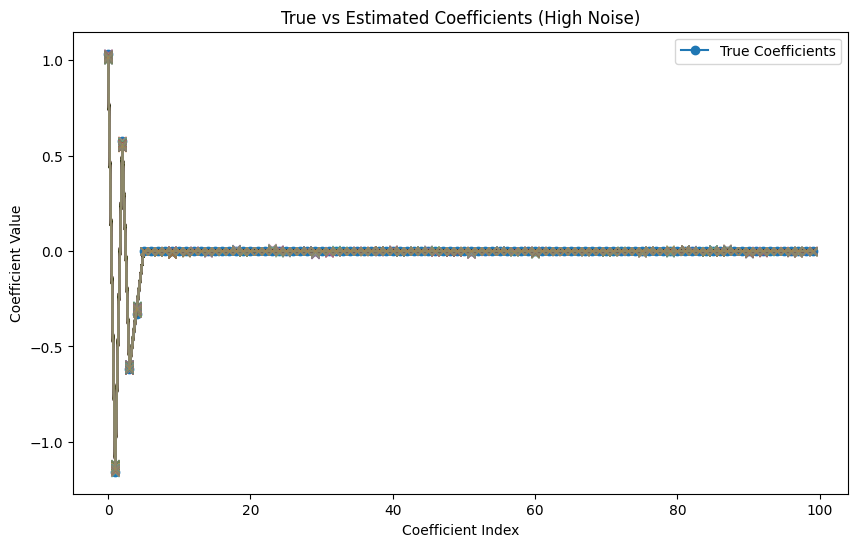

In [6]:
#visualization of coefficients
plt.figure(figsize=(10, 6))
plt.plot(beta, label='True Coefficients', marker='o')
for i in range(len(results['coefficients'])):
    plt.plot(results['coefficients'][i], label='', marker='x', alpha=0.3)
plt.legend()
plt.title('True vs Estimated Coefficients (High Noise)')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.show()

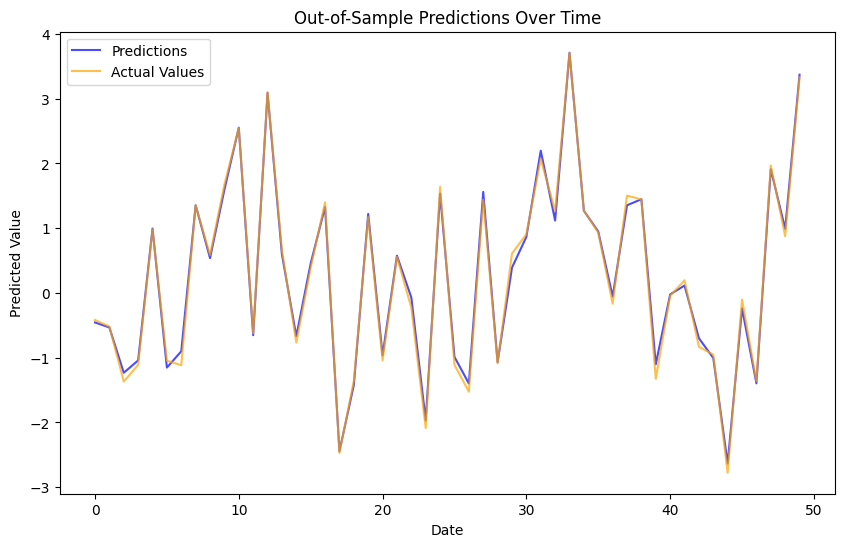

In [7]:
zoom_in_range = range(0, 50)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results['predictions'][zoom_in_range], label='Predictions', color='blue', alpha = 0.7)
ax.set_title('Out-of-Sample Predictions Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Predicted Value')
#add the actual values
ax.plot(results['targets'][zoom_in_range], label='Actual Values', color='orange', alpha = 0.7)
ax.legend()
plt.show()



In [ ]:
## Case 2) with lagged features

def generate_synthetic_data_1_lag(n_samples: int, n_features: int, n_informative: int, noise: float = 0.1, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    coef = np.zeros(2 * n_features)
    coef[:n_informative] = np.random.randn(n_informative)
    beta = coef.copy()

    X_lag1 = np.roll(X, shift=1, axis=0)
    X_lag2 = np.roll(X, shift=2, axis=0)
    X_lagged = np.hstack([X_lag1, X_lag2])
    X_lagged[:2, :] = 0  # Handle the first two rows

    y = X_lagged @ coef + noise * np.random.randn(n_samples)
    return X, y, beta

In [14]:
#create df to simulate date index
X_lagged, y_lagged, beta_lagged = generate_synthetic_data_1_lag(n_samples=1000, n_features=20, n_informative=5)
dates = pd.date_range(start='2000-01-01', periods=len(y_lagged), freq='D')
y_series_lagged = pd.Series(y_lagged, index=dates)
X_df_lagged = pd.DataFrame(X_lagged, index=dates, columns=[f'feature_{i}' for i in range(X_lagged.shape[1])])
results_lagged = lasso_rolling_window(X_df_lagged, y_series_lagged, window_size=200, n_lags=2, standardize=True, cv_folds=5, lambda_mode="cv", verbose=True)

Creating lagged features with 2 lags...
Running 799 rolling windows of size 200...
Lambda selection: cross-validation


Rolling windows: 100%|██████████| 799/799 [00:10<00:00, 79.85it/s]

Rolling Estimation complete!


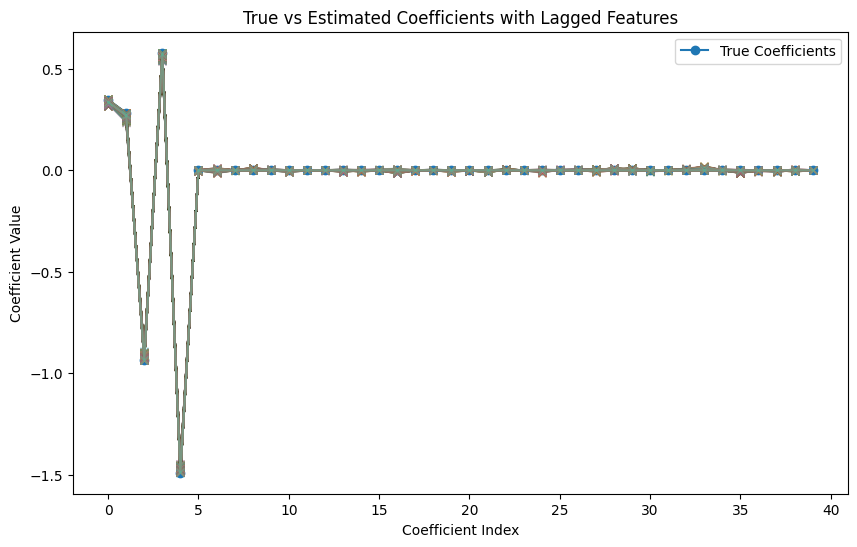

In [15]:
#visualization of coefficients
plt.figure(figsize=(10, 6))
plt.plot(beta_lagged, label='True Coefficients', marker='o')
for i in range(len(results_lagged['coefficients'])):
    plt.plot(results_lagged['coefficients'][i], label='', marker='x', alpha=0.3)
plt.legend()
plt.title('True vs Estimated Coefficients with Lagged Features')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.show()


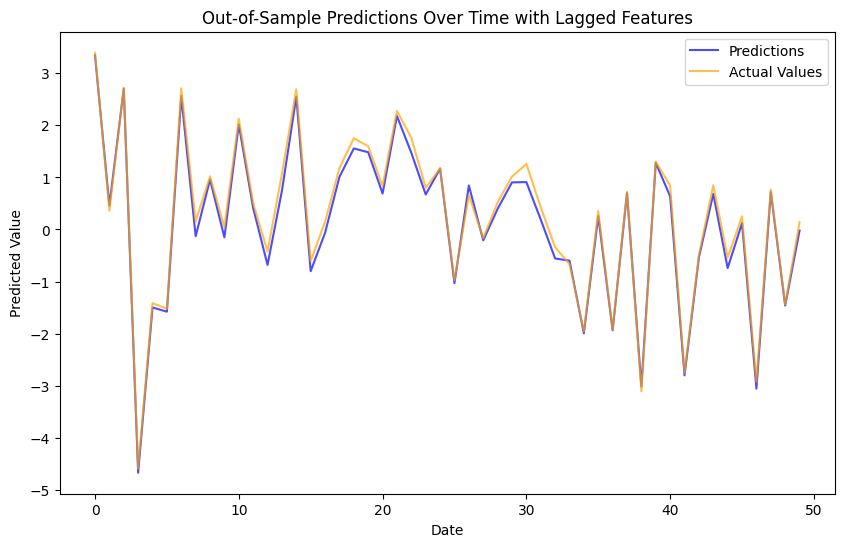

In [16]:
#predictions vs actuals plot
zoom_in_range = range(0, 50)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_lagged['predictions'][zoom_in_range], label='Predictions', color='blue', alpha = 0.7)
ax.set_title('Out-of-Sample Predictions Over Time with Lagged Features')
ax.set_xlabel('Date')
ax.set_ylabel('Predicted Value')
#add the actual values
ax.plot(results_lagged['targets'][zoom_in_range], label='Actual Values', color='orange', alpha = 0.7)
ax.legend()
plt.show()


In [21]:
## Case 3) with 3 lagged features and higher number of paramters and features

def generate_synthetic_data_3_lags(n_samples: int, n_features: int, n_informative: int, noise: float = 0.1, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    coef = np.zeros(3 * n_features)
    #draw informative coefficients from all lags
    indexes = np.random.choice(3 * n_features, n_informative, replace=False)
    coef[indexes] = np.random.randn(n_informative)
    beta = coef.copy()

    X_lag1 = np.roll(X, shift=1, axis=0)
    X_lag2 = np.roll(X, shift=2, axis=0)
    X_lag3 = np.roll(X, shift=3, axis=0)
    X_lagged = np.hstack([X_lag1, X_lag2, X_lag3])
    X_lagged[:3, :] = 0  # Handle the first three rows

    y = X_lagged @ coef + noise * np.random.randn(n_samples)
    return X, y, beta

In [22]:
#create df to simulate date index
X_lagged3, y_lagged3, beta_lagged3 = generate_synthetic_data_3_lags(n_samples=1000, n_features=40, n_informative=20)
dates3 = pd.date_range(start='2000-01-01', periods=len(y_lagged3), freq='D')
y_series_lagged3 = pd.Series(y_lagged3, index=dates3)
X_df_lagged3 = pd.DataFrame(X_lagged3, index=dates3, columns=[f'feature_{i}' for i in range(X_lagged3.shape[1])])
results_lagged3 = lasso_rolling_window(X_df_lagged3, y_series_lagged3, window_size=500, n_lags=3, standardize=True, cv_folds=5, lambda_mode="cv", verbose=True)

Creating lagged features with 3 lags...
Running 498 rolling windows of size 500...
Lambda selection: cross-validation


Rolling windows: 100%|██████████| 498/498 [00:09<00:00, 53.88it/s]

Rolling Estimation complete!


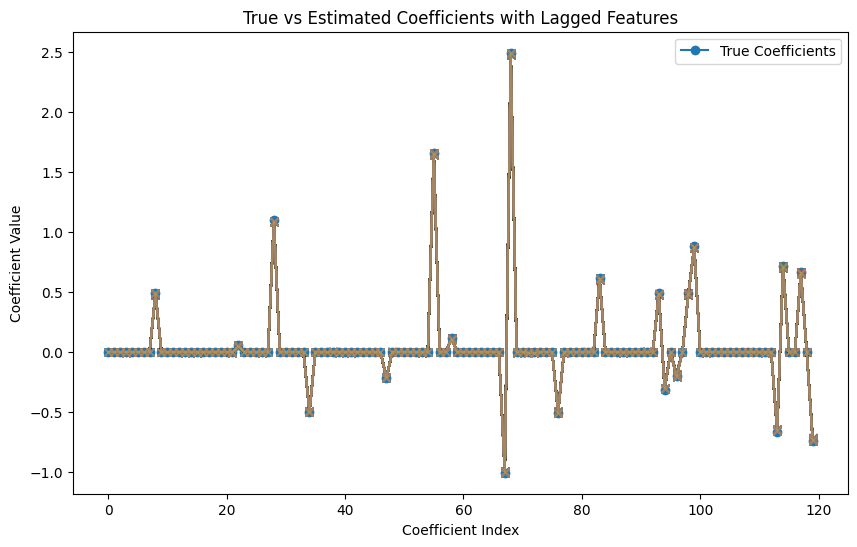

In [23]:
#visualization of coefficients
plt.figure(figsize=(10, 6))
plt.plot(beta_lagged3, label='True Coefficients', marker='o')
for i in range(len(results_lagged3['coefficients'])):
    plt.plot(results_lagged3['coefficients'][i], label='', marker='x', alpha=0.3)
plt.legend()
plt.title('True vs Estimated Coefficients with Lagged Features')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.show()

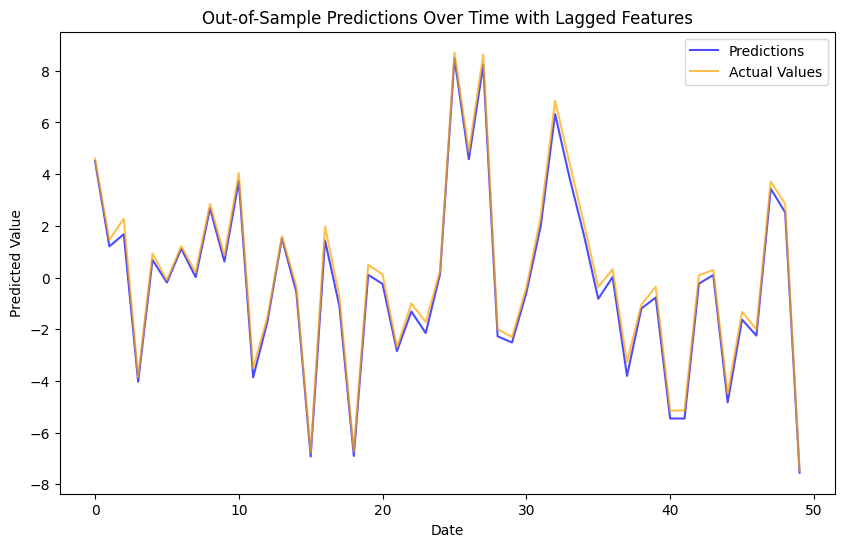

In [24]:
#predictions vs actuals plot
zoom_in_range = range(0, 50)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_lagged3['predictions'][zoom_in_range], label='Predictions', color='blue', alpha = 0.7)
ax.set_title('Out-of-Sample Predictions Over Time with Lagged Features')
ax.set_xlabel('Date')
ax.set_ylabel('Predicted Value')
#add the actual values
ax.plot(results_lagged3['targets'][zoom_in_range], label='Actual Values', color='orange', alpha = 0.7)
ax.legend()
plt.show()